# AD688 Group 3 - Step 2 Filtering: Insurance Carriers, All Roles (PySpark on AWS EC2)

**Track:** Team project, Step 2 (Data Preparation and Market Baseline).

**Engine:** PySpark, running on the AWS EC2 instance (the class-proper toolchain).

**Goal:** filter the job postings down to the Insurance Carriers industry (NAICS 5241),keeping every role, not just data roles, and flag which postings match our data-role scope. 

This is the team's master dataset going forward. Everything is included, and
`IS_DATA_ROLE_MATCH` column marks the ones relevant to the data-role analysis, so the team can sort/filter to that subset in Excel or widen the view as needed.

Run the cells top to bottom. Each one prints its output right below it. 


## 1. Start Spark and load the data

Spark is the query engine. We point it at the 17 Parquet files and load them as one table. 

In [187]:
from pathlib import Path
from pyspark.sql import SparkSession

# Start or reuse the Spark session
spark = (
    SparkSession.builder
    .appName("AD688-Step2-Insurance")
    .master("local[1]")
    .config("spark.driver.memory", "512m")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

# Find the project root
project_root = Path.cwd()

while not (project_root / "_quarto.yml").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not find the project root.")
    project_root = project_root.parent

# Shared team dataset
csv_path = (
    project_root
    / "outputs"
    / "step2"
    / "insurance_5241_all_postings.csv"
)

print("Dataset path:", csv_path)

if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path}")

# Load the shared Insurance 5241 dataset
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("quote", '"')
    .option("escape", '"')
    .csv(str(csv_path))
)

# Make the DataFrame available for Spark SQL
df.createOrReplaceTempView("jobs")

print("Dataset loaded successfully")
print("Rows:", df.count())
print("Columns:", len(df.columns))
print("SQL table 'jobs' is ready.")

Dataset path: /home/ubuntu/ad688group3.github.io/outputs/step2/insurance_5241_all_postings.csv
Dataset loaded successfully
Rows: 1895
Columns: 34
SQL table 'jobs' is ready.


## 2. Register the data as a SQL table

This lets us query the postings with plain SQL and name the table `jobs`.

In [188]:
# Register the DataFrame as a temporary SQL table named "jobs" so the next cell can
# query it with plain SQL (SELECT / WHERE) instead of PySpark method chains.
df.createOrReplaceTempView("jobs")
print("Table 'jobs' is ready to query.")

Table 'jobs' is ready to query.


## 3. Filter to Insurance Carriers (NAICS 5241), flagged for data-role titles

Keep every posting in the Insurance Carriers industry (NAICS code 5241),
regardless of job title - nothing gets dropped, this is still the full industry cross-section. 

The one addition is a new column, `IS_DATA_ROLE_MATCH`, placed right
after `TITLE_CLEAN`: it's 1 for postings whose title matches our data-role keyword set (data engineer, data scientist, data analyst / BI, data architect / DBA, data governance, ML engineer, etc), and 0 for everything else. 

Sorting or filtering on this column in Excel is how the team can hone in on data roles specifically, without losing the rest of the dataset to work from.

In [189]:
# This is still the full Insurance Carrier (NAICS 5241) slice - every role, nothing
# filtered out. The only addition is IS_DATA_ROLE_MATCH, a 1/0 flag placed right after
# TITLE_CLEAN, using our data-role keyword regex. Rows flagged 1 are the data-role subset.
query = """
SELECT
  -- Core identifiers and posting metadata
  ID, POSTED, EXPIRED, DURATION, URL,
  -- Job title fields (raw text plus Lightcast's cleaned versions)
  TITLE_RAW, TITLE_NAME, TITLE_CLEAN,
  -- Flag: 1 if this title matches the data-role keyword set, 0 otherwise. Does not
  -- drop any rows - just marks which ones are in the data-role scope.
  CASE WHEN lower(TITLE_RAW) RLIKE 'data engineer|analytics engineer|etl|data pipeline|data platform|big data|ml engineer|machine learning engineer|data architect|database|data scientist|data science|data analyst|business intelligence| bi |data governance|data management'
       THEN 1 ELSE 0 END AS IS_DATA_ROLE_MATCH,
  -- Employer info
  COMPANY_NAME, COMPANY_IS_STAFFING, EMPLOYMENT_TYPE_NAME,
  -- Experience and education requirements
  MIN_YEARS_EXPERIENCE, MAX_YEARS_EXPERIENCE, IS_INTERNSHIP,
  MIN_EDULEVELS_NAME, MAX_EDULEVELS_NAME,
  -- Pay
  SALARY, SALARY_FROM, SALARY_TO, ORIGINAL_PAY_PERIOD,
  -- Location and remote status
  REMOTE_TYPE_NAME, LOCATION, CITY_NAME, STATE_NAME, MSA_NAME,
  -- Industry and occupation codes
  NAICS_2022_4, SOC_2021_4_NAME, ONET_NAME,
  -- Skills and certifications requested in the posting
  SKILLS_NAME, SPECIALIZED_SKILLS_NAME, COMMON_SKILLS_NAME,
  SOFTWARE_SKILLS_NAME, CERTIFICATIONS_NAME
FROM jobs
WHERE NAICS_2022_4 = '5241'
ORDER BY TITLE_NAME, TITLE_RAW
"""
insurance = spark.sql(query)
insurance.createOrReplaceTempView("insurance_jobs")
print("Insurance Carrier (NAICS 5241) postings:", insurance.count())
print("Rows flagged IS_DATA_ROLE_MATCH = 1:", insurance.filter("IS_DATA_ROLE_MATCH = 1").count())

Insurance Carrier (NAICS 5241) postings: 1895
Rows flagged IS_DATA_ROLE_MATCH = 1: 27


## 4. See the results

A preview of the postings, and the most common job titles in this slice so the team
can get a feel for what's in here before deciding how to narrow it down.

In [190]:
# Preview the postings, including the new flag, and the most common job titles.
insurance.select("TITLE_RAW", "TITLE_NAME", "IS_DATA_ROLE_MATCH", "COMPANY_NAME",
                  "STATE_NAME", "REMOTE_TYPE_NAME", "SALARY_FROM").show(30, truncate=False)

print("Most common job titles (TITLE_NAME), top 25:")
insurance.groupBy("TITLE_NAME").count().orderBy("count", ascending=False).show(25, truncate=False)

+------------------------------------------------------------------------+------------------------+------------------+---------------------------+---------------------+----------------+-----------+
|TITLE_RAW                                                               |TITLE_NAME              |IS_DATA_ROLE_MATCH|COMPANY_NAME               |STATE_NAME           |REMOTE_TYPE_NAME|SALARY_FROM|
+------------------------------------------------------------------------+------------------------+------------------+---------------------------+---------------------+----------------+-----------+
|Accountant                                                              |Accountants and Auditors|0                 |Jobs.danaher.com           |California           |Unknown         |NULL       |
|Accountant                                                              |Accountants and Auditors|0                 |Bannerlife                 |Maryland             |Unknown         |NULL       |
|Accountan

## 5. Export for the team (Excel + CSV)

This is bigger than the 27-row data-role cut (about 1,900 rows), but still small enough
to pull into pandas and write out directly.

In [191]:
# Pull the full Insurance Carrier slice into pandas and write it out as both Excel
# and CSV, so the team has one shared file to review and narrow down from.
import os

os.makedirs("outputs/step2", exist_ok=True)
pdf = insurance.toPandas()

xlsx_path = "outputs/step2/insurance_5241_all_postings.xlsx"
csv_path  = "outputs/step2/insurance_5241_all_postings.csv"
pdf.to_excel(xlsx_path, index=False)
pdf.to_csv(csv_path, index=False)

print("Rows exported:", len(pdf))
print("Excel:", os.path.abspath(xlsx_path))
print("CSV:  ", os.path.abspath(csv_path))

Rows exported: 1895
Excel: /home/ubuntu/ad688group3.github.io/notebooks/outputs/step2/insurance_5241_all_postings.xlsx
CSV:   /home/ubuntu/ad688group3.github.io/notebooks/outputs/step2/insurance_5241_all_postings.csv


## 6. What this produced

- The team's master dataset: the full Insurance Carrier (NAICS 5241) posting set, every
  role, nothing filtered out.
- A new `IS_DATA_ROLE_MATCH` column (1/0) right after `TITLE_CLEAN`, flagging postings
  that match our data-role keyword set. Sort or filter on that column in Excel/CSV to
  jump straight to the data roles, or clear the filter to see everything else in the
  industry.
- Two export files in `outputs/step2/` (Excel and CSV): `insurance_5241_all_postings`.
  This is the file the team should use going forward.

## 7. Core Variable Cleaning and Market Baseline

This section continues from the Insurance Carrier (NAICS 5241) dataset prepared above.
The analysis focuses on the data-related roles identified by `IS_DATA_ROLE_MATCH`
and cleans the core variables needed for the market baseline analysis.

In [192]:
# Select the data-related roles identified in the previous filtering step.
data_roles_df = spark.sql("""
SELECT *
FROM jobs
WHERE IS_DATA_ROLE_MATCH = 1
""")

print("Data-related postings:", data_roles_df.count())

Data-related postings: 27


### 8. Remove Duplicate Job Postings

In [193]:
before = data_roles_df.count()

clean_df = data_roles_df.dropDuplicates(["ID"])

after = clean_df.count()

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Duplicates removed:", before - after)

Rows before duplicate removal: 27
Rows after duplicate removal: 27
Duplicates removed: 0


### 9. Clean and Review Salary Variables

Salary fields are reviewed for missing values and pay-period consistency before they are used in the market baseline analysis.

In [194]:
# Check salary availability and pay-period values
clean_df.createOrReplaceTempView("clean_jobs")

spark.sql("""
SELECT
    ORIGINAL_PAY_PERIOD,
    COUNT(*) AS postings,
    SUM(CASE WHEN SALARY_FROM IS NOT NULL THEN 1 ELSE 0 END) AS with_salary_from,
    SUM(CASE WHEN SALARY_TO IS NOT NULL THEN 1 ELSE 0 END) AS with_salary_to
FROM clean_jobs
GROUP BY ORIGINAL_PAY_PERIOD
ORDER BY postings DESC
""").show(truncate=False)

spark.sql("""
SELECT
    TITLE_CLEAN,
    SALARY_FROM,
    SALARY_TO,
    ORIGINAL_PAY_PERIOD
FROM clean_jobs
ORDER BY SALARY_FROM DESC
""").show(27, truncate=False)

+-------------------+--------+----------------+--------------+
|ORIGINAL_PAY_PERIOD|postings|with_salary_from|with_salary_to|
+-------------------+--------+----------------+--------------+
|NULL               |21      |0               |0             |
|annual             |6       |5               |5             |
+-------------------+--------+----------------+--------------+

+---------------------------------------------------------------------------------------------------+-----------+---------+-------------------+
|TITLE_CLEAN                                                                                        |SALARY_FROM|SALARY_TO|ORIGINAL_PAY_PERIOD|
+---------------------------------------------------------------------------------------------------+-----------+---------+-------------------+
|Data Scientist                                                                                     |210000.0   |350000.0 |annual             |
|Senior Data Analyst                         

## 10. Salary
Salary information was available for 5 of the 27 data-related postings.
The average annual salary midpoint among those postings was $163,840,
with midpoint values ranging from $93,000 to $280,000.
Missing salary values were left as missing rather than imputed.


In [195]:
from pyspark.sql import functions as F

clean_df = clean_df.withColumn(
    "ANNUAL_SALARY_MIDPOINT",
    F.when(
        (F.lower(F.col("ORIGINAL_PAY_PERIOD")) == "annual") &
        F.col("SALARY_FROM").isNotNull() &
        F.col("SALARY_TO").isNotNull(),
        (F.col("SALARY_FROM") + F.col("SALARY_TO")) / 2
    )
)

clean_df.select(
    "TITLE_CLEAN",
    "SALARY_FROM",
    "SALARY_TO",
    "ORIGINAL_PAY_PERIOD",
    "ANNUAL_SALARY_MIDPOINT"
).show(27, truncate=False)

clean_df.createOrReplaceTempView("clean_jobs")

spark.sql("""
SELECT
    COUNT(ANNUAL_SALARY_MIDPOINT) AS postings_with_salary,
    ROUND(AVG(ANNUAL_SALARY_MIDPOINT), 2) AS average_salary_midpoint,
    ROUND(MIN(ANNUAL_SALARY_MIDPOINT), 2) AS minimum_salary_midpoint,
    ROUND(MAX(ANNUAL_SALARY_MIDPOINT), 2) AS maximum_salary_midpoint
FROM clean_jobs
""").show()

+---------------------------------------------------------------------------------------------------+-----------+---------+-------------------+----------------------+
|TITLE_CLEAN                                                                                        |SALARY_FROM|SALARY_TO|ORIGINAL_PAY_PERIOD|ANNUAL_SALARY_MIDPOINT|
+---------------------------------------------------------------------------------------------------+-----------+---------+-------------------+----------------------+
|Data Scientist                                                                                     |210000.0   |350000.0 |annual             |280000.0              |
|Data Analyst — AI-Driven Insights                                                                  |74000.0    |112000.0 |annual             |93000.0               |
|Staff Data Engineer, Finance                                                                       |NULL       |NULL     |NULL               |NULL                  

### 11. Clean and Review Experience Requirements
Experience requirements were not available in the structured
`MIN_YEARS_EXPERIENCE` or `MAX_YEARS_EXPERIENCE` fields for any of the
27 data-related postings. Because no structured experience values were
available, these fields were retained as missing and excluded from the
market baseline calculations.

In [196]:
clean_df.select(
    "TITLE_CLEAN",
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE"
).show(27, truncate=False)

clean_df.createOrReplaceTempView("clean_jobs")

spark.sql("""
SELECT
    COUNT(*) AS total_postings,
    SUM(CASE WHEN MIN_YEARS_EXPERIENCE IS NOT NULL THEN 1 ELSE 0 END) AS with_min_experience,
    SUM(CASE WHEN MAX_YEARS_EXPERIENCE IS NOT NULL THEN 1 ELSE 0 END) AS with_max_experience
FROM clean_jobs
""").show()

+---------------------------------------------------------------------------------------------------+--------------------+--------------------+
|TITLE_CLEAN                                                                                        |MIN_YEARS_EXPERIENCE|MAX_YEARS_EXPERIENCE|
+---------------------------------------------------------------------------------------------------+--------------------+--------------------+
|Data Scientist                                                                                     |NULL                |NULL                |
|Data Analyst — AI-Driven Insights                                                                  |NULL                |NULL                |
|Staff Data Engineer, Finance                                                                       |NULL                |NULL                |
|Data Governance & Metadata Scientist                                                               |NULL                |NULL          

### 12. Clean Location and Remote Work Variables

Location fields were reviewed for missing and inconsistent values. 
The `STATE_NAME` field contains some non-state labels, so a cleaned state variable
is created before geographic analysis. Remote-work categories are retained separately.

Valid state information was available for only 9 of the 27 data-related postings, so
geographic comparisons should be interpreted cautiously. Remote-work information was
more complete, with 12 remote postings, 4 hybrid postings, 3 on-site postings, and
8 postings with an unknown work arrangement.

In [197]:
from pyspark.sql import functions as F

valid_states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
    "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho",
    "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
    "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
    "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada",
    "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming", "District of Columbia"
]

clean_df = clean_df.withColumn(
    "CLEAN_STATE",
    F.when(
        F.col("STATE_NAME").isin(valid_states),
        F.col("STATE_NAME")
    )
)


clean_df = clean_df.withColumn(
    "WORK_ARRANGEMENT",
    F.when(F.col("REMOTE_TYPE_NAME") == "Remote", "Remote")
     .when(F.col("REMOTE_TYPE_NAME") == "Hybrid", "Hybrid")
     .when(F.col("REMOTE_TYPE_NAME") == "On-site", "On-site")
     .otherwise("Unknown")
)

clean_df.createOrReplaceTempView("clean_jobs")

spark.sql("""
SELECT
    CLEAN_STATE,
    COUNT(*) AS postings
FROM clean_jobs
GROUP BY CLEAN_STATE
ORDER BY postings DESC
""").show(50, truncate=False)


spark.sql("""
SELECT
    WORK_ARRANGEMENT,
    COUNT(*) AS postings
FROM clean_jobs
GROUP BY WORK_ARRANGEMENT
ORDER BY postings DESC
""").show(truncate=False)


+--------------------+--------+
|CLEAN_STATE         |postings|
+--------------------+--------+
|NULL                |18      |
|California          |2       |
|Ohio                |1       |
|Washington          |1       |
|Illinois            |1       |
|District of Columbia|1       |
|New Jersey          |1       |
|Maryland            |1       |
|Florida             |1       |
+--------------------+--------+

+----------------+--------+
|WORK_ARRANGEMENT|postings|
+----------------+--------+
|Remote          |12      |
|Unknown         |8       |
|Hybrid          |4       |
|On-site         |3       |
+----------------+--------+



### 13. Clean and Analyze Skills

Skill fields are converted from stored list strings into individual skills so that
the most frequently requested skills can be identified across the data-related postings.

General skill information was available for 25 of the 27 data-related postings, and
specialized skill information was available for 24 postings. The software-skill and
certification fields contained no usable values, so they were excluded from the market
baseline analysis.

In [198]:
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType

# Convert the stored skill-list strings into Spark arrays
skills_df = (
    clean_df
    .withColumn(
        "SKILLS_ARRAY",
        F.from_json("SKILLS_NAME", ArrayType(StringType()))
    )
    .withColumn(
        "SPECIALIZED_ARRAY",
        F.from_json("SPECIALIZED_SKILLS_NAME", ArrayType(StringType()))
    )
    .withColumn(
        "SOFTWARE_ARRAY",
        F.from_json("SOFTWARE_SKILLS_NAME", ArrayType(StringType()))
    )
    .withColumn(
        "CERTIFICATIONS_ARRAY",
        F.from_json("CERTIFICATIONS_NAME", ArrayType(StringType()))
    )
)

# Check how many postings contain usable skill information
skills_df.select(
    F.count("*").alias("total_postings"),
    F.sum(
        F.when(F.size("SKILLS_ARRAY") > 0, 1).otherwise(0)
    ).alias("with_skills"),
    F.sum(
        F.when(F.size("SPECIALIZED_ARRAY") > 0, 1).otherwise(0)
    ).alias("with_specialized_skills"),
    F.sum(
        F.when(F.size("SOFTWARE_ARRAY") > 0, 1).otherwise(0)
    ).alias("with_software_skills"),
    F.sum(
        F.when(F.size("CERTIFICATIONS_ARRAY") > 0, 1).otherwise(0)
    ).alias("with_certifications")
).show()

+--------------+-----------+-----------------------+--------------------+-------------------+
|total_postings|with_skills|with_specialized_skills|with_software_skills|with_certifications|
+--------------+-----------+-----------------------+--------------------+-------------------+
|            27|         25|                     24|                   0|                  0|
+--------------+-----------+-----------------------+--------------------+-------------------+



In [199]:
total_postings = clean_df.count()

top_specialized = (
    skills_df
    .select(
        F.explode_outer("SPECIALIZED_ARRAY").alias("SPECIALIZED_SKILL")
    )
    .filter(F.col("SPECIALIZED_SKILL").isNotNull())
    .groupBy("SPECIALIZED_SKILL")
    .count()
    .withColumn(
        "percent_of_postings",
        F.round((F.col("count") / total_postings) * 100, 1)
    )
    .orderBy(F.desc("count"), "SPECIALIZED_SKILL")
)

top_specialized.show(15, truncate=False)

+---------------------+-----+-------------------+
|SPECIALIZED_SKILL    |count|percent_of_postings|
+---------------------+-----+-------------------+
|Analytics            |16   |59.3               |
|Automation           |6    |22.2               |
|Business Intelligence|5    |18.5               |
|Accounting           |4    |14.8               |
|Airflow              |3    |11.1               |
|BigQuery             |3    |11.1               |
|AI Agents            |2    |7.4                |
|Advanced Analytics   |2    |7.4                |
|Agentic Systems      |2    |7.4                |
|Azure Data Lake      |2    |7.4                |
|Batch Processing     |2    |7.4                |
|Business Requirements|2    |7.4                |
|AI Innovation        |1    |3.7                |
|Access Controls      |1    |3.7                |
|Accounts Receivable  |1    |3.7                |
+---------------------+-----+-------------------+
only showing top 15 rows


### 14. Market Baseline Summary
The market baseline summarizes the 27 data-related postings identified within
Insurance Carriers (NAICS 5241). The baseline focuses on job availability,
salary information, work arrangement, geography, and commonly requested skills.

In [200]:
from pyspark.sql import functions as F

total_jobs = clean_df.count()

salary_stats = clean_df.select(
    F.count("ANNUAL_SALARY_MIDPOINT").alias("salary_postings"),
    F.round(F.avg("ANNUAL_SALARY_MIDPOINT"), 2).alias("avg_salary_midpoint")
).first()

remote_jobs = clean_df.filter(
    F.col("WORK_ARRANGEMENT") == "Remote"
).count()

hybrid_jobs = clean_df.filter(
    F.col("WORK_ARRANGEMENT") == "Hybrid"
).count()

onsite_jobs = clean_df.filter(
    F.col("WORK_ARRANGEMENT") == "On-site"
).count()

print("MARKET BASELINE")
print("------------------------------")
print("Data-related postings:", total_jobs)
print("Postings with salary:", salary_stats["salary_postings"])
print("Average salary midpoint:", salary_stats["avg_salary_midpoint"])
print("Remote postings:", remote_jobs)
print("Hybrid postings:", hybrid_jobs)
print("On-site postings:", onsite_jobs)

MARKET BASELINE
------------------------------
Data-related postings: 27
Postings with salary: 5
Average salary midpoint: 163840.0
Remote postings: 12
Hybrid postings: 4
On-site postings: 3


Among the 27 data-related Insurance postings, remote work was the most common
identified work arrangement, with 12 remote postings compared with 4 hybrid
and 3 on-site postings. Salary information was limited to 5 postings, with an
average annual salary midpoint of approximately $163,840, so salary findings
should be interpreted cautiously.

Skills were more consistently available. Analytics appeared in 59.3% of the
postings, followed by Automation (22.2%) and Business Intelligence (18.5%).
Technical data-engineering skills such as Airflow and BigQuery each appeared
in 11.1% of the postings.

### 15. Market Baseline Visualizations

The following visualizations summarize work arrangement and the most frequently requested specialized skills among the identified data-related postings.

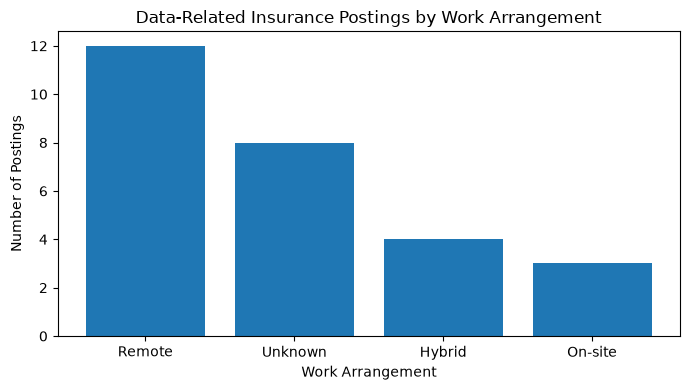

In [201]:
import matplotlib.pyplot as plt

work_arrangement_pd = (
    clean_df
    .groupBy("WORK_ARRANGEMENT")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

plt.figure(figsize=(7, 4))
plt.bar(
    work_arrangement_pd["WORK_ARRANGEMENT"],
    work_arrangement_pd["count"]
)

plt.title("Data-Related Insurance Postings by Work Arrangement")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Postings")
plt.tight_layout()
plt.show()

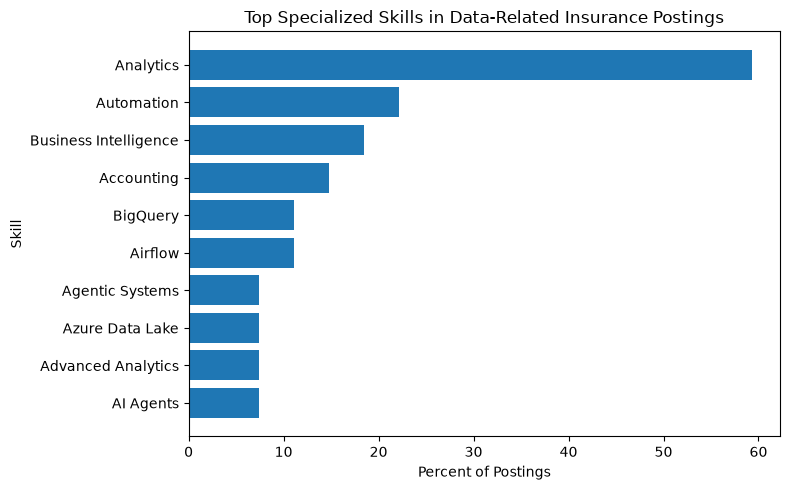

In [202]:
top_skills_pd = (
    top_specialized
    .limit(10)
    .toPandas()
    .sort_values("percent_of_postings")
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_skills_pd["SPECIALIZED_SKILL"],
    top_skills_pd["percent_of_postings"]
)

plt.title("Top Specialized Skills in Data-Related Insurance Postings")
plt.xlabel("Percent of Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [203]:
# Save cleaned dataset
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = (
    processed_dir /
    "insurance_5241_data_roles_cleaned.csv"
)

clean_df.toPandas().to_csv(
    processed_path,
    index=False
)

print("Cleaned dataset saved to:", processed_path)

Cleaned dataset saved to: /home/ubuntu/ad688group3.github.io/data/processed/insurance_5241_data_roles_cleaned.csv


### 16. Key Findings and Limitations

The analysis identified 27 data-related job postings within Insurance Carriers
(NAICS 5241). No duplicate job IDs were found.

Remote work was the most common identified work arrangement, with 12 remote
postings, compared with 4 hybrid and 3 on-site postings.

Salary information was available for only 5 postings. Among those postings,
the average annual salary midpoint was approximately $163,840. Because salary
information was unavailable for most postings, this result should be interpreted
cautiously.

Skills information was more complete. Analytics was the most frequently
identified specialized skill, appearing in 59.3% of postings. Automation
appeared in 22.2%, Business Intelligence in 18.5%, and Airflow and BigQuery
each appeared in 11.1%.

Structured experience information was unavailable for all 27 postings, and
valid state information was available for only a subset of postings. These
limitations restrict conclusions about experience requirements and geographic
demand.

When done, stop Spark to free memory:

In [204]:
# Release Spark's memory now that we're done with it.
spark.stop()
print("Spark stopped.")

Spark stopped.
